In [31]:
import matplotlib.pyplot as plt
import numpy as np
import time

# from multiprocessing.dummy import Pool as ThreadPool
from concurrent.futures import ProcessPoolExecutor

### Simulate BDM

$$
dX_t = k  (\mu - X_t) dt + D \sqrt{X_t} dW_t
$$

Update rule : $X_{t + dt} = X_t + k(\mu - X_t)dt + D \sqrt{X_t} \eta$

In [32]:
def BDM_step(X0, k, mu, D, dt, timestepsperpoint):
    t = np.linspace(0, timestepsperpoint - 1, timestepsperpoint)
    X = np.zeros(timestepsperpoint)
    X[0] = X0

    dW = D * np.random.normal(size=timestepsperpoint)

    #Euler-Maruyama iteration
    for i in range(1,timestepsperpoint):
        X[i] = X[i-1] + k * (mu - X[i-1]) * dt + np.sqrt(X[i-1]) * dW[i-1]

    return X[-1]

In [33]:
def BDM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N):
    datapoints = np.zeros(N)
    datapoints[0] = X0

    for idx in range(1,N):
        datapoints[idx] = BDM_step(datapoints[idx-1], k, mu, D, dt, timestepsperpoint)

    return datapoints

### Simulate SLM

$$
dX_t = k  X_t (\mu - X_t) dt + D X_t dW_t
$$

Update rule : $ X_{t + dt} = X_t + k X_t ( \mu - X_t) dt + D X_t \eta $

In [34]:
def SLM_step(X0, k, mu, D, dt, timestepsperpoint):
    t = np.linspace(0, timestepsperpoint - 1, timestepsperpoint)
    X = np.zeros(timestepsperpoint)
    X[0] = X0

    dW = D * np.random.normal(size=timestepsperpoint)

    #Euler-Maruyama iteration
    for i in range(1,timestepsperpoint):
        X[i] = X[i-1] + k * X[i-1] * (mu - X[i-1]) * dt + X[i-1] * dW[i-1]

    return X[-1]

In [35]:
def SLM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N):
    datapoints = np.zeros(N)
    datapoints[0] = X0

    for idx in range(1,N):
        datapoints[idx] = SLM_step(datapoints[idx-1], k, mu, D, dt, timestepsperpoint)

    return datapoints

### Wrapper Function

In [36]:
def simulate_timeseries(model='BDM', params=None):
    
    valid_models = {"BDM", "SLM"}
    X0, k, mu, D, dt, timestepsperpoint, N = params

    if params == None:
        raise ValueError("No parameters passed to simulate_timeseries()!")
    
    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        sim_data = BDM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N)
    elif model == 'SLM':
        sim_data = SLM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N)

    return sim_data

### Simulation Parameters

In [37]:
MODEL = 'SLM'

In [38]:
X0 = 4.5
k = 3
mu = 5
D = 0.005

dt = 3e-3 #timestep of the simulation

T = 100 #timeseries timespan, starts at 0 and ends at T
eff_dt = 1 #timestep of the datapoints
N = round(T+1 / eff_dt) #number of datapoints

timestepsperpoint = round(eff_dt / dt)

### Run simulation and visualize

In [39]:
sim_data = simulate_timeseries(model=MODEL, params=(X0, k, mu, D, dt, timestepsperpoint, N))

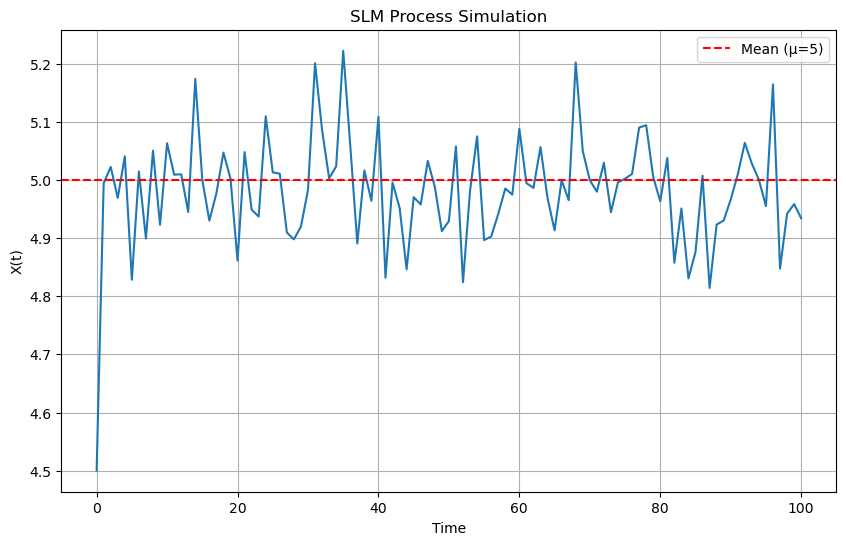

In [40]:
# Plot result
plt.figure(figsize=(10, 6))
timepoints = np.linspace(0, T, N)
plt.plot(timepoints, sim_data)
plt.axhline(y=mu, color='r', linestyle='--', label=f'Mean (μ={mu})')
plt.xlabel('Time')
plt.ylabel('X(t)')
plt.title(f'{MODEL} Process Simulation')
plt.legend()
plt.grid(True)
plt.show()

In [41]:
def BDM_Lamperti(ts_data):
    arr = np.array(ts_data)      
    # Check for negative values
    if np.any(arr < 0):
        raise ValueError("Input array contains negative values. Square root is not defined for negative numbers.")    
    result = 2 * np.sqrt(arr)
    return result
    
def SLM_Lamperti(ts_data):
    arr = np.array(ts_data)      
    # Check for negative values
    if np.any(arr < 0):
        raise ValueError("Input array contains negative values. Log is not defined for negative numbers.")    
    result = np.log(arr)
    return result

In [42]:
# Parameters
NB = 10000  # Number of bridges per transition
timestep_ratio = 1e3 # dt / Dt

bridge_steps = int(eff_dt * timestep_ratio) # Number of time steps inside bridge
Delta_t_B = eff_dt / bridge_steps 

datapoint_times = np.linspace(0, T, N)

In [43]:
def bridge(NB, bridge_steps, x_i, x_f, Delta_t_B, D):        
    B = np.empty((NB, bridge_steps), dtype=np.float32) #to store simulated X values for bridges
    B[:, 0] = x_i
    B[:, -1] = x_f     
    for step in range(1, bridge_steps - 1): 
        #ATTENTION: Manal's script had (bridge_steps - step) * B[:, step - 1] + x_f with a PLUS!! Is this a grave typo in Javier's?
        mean_b = ((bridge_steps - step) * B[:, step - 1] + x_f ) / (bridge_steps - step + 1)        
        var_b = (D**2 * (bridge_steps - step) * Delta_t_B ) / (bridge_steps - step + 1)      
        B[:, step] = np.random.randn(NB) * np.sqrt(var_b) + mean_b    
    return B

In [44]:
#This is not necessary, but useful to keep.

def A_BDM(k, mu, x):
    return (2 * k * mu - 0.5 * k * x**2 - 0.5) / x

def A_SLM(k, mu, x):
    return k * (mu - np.exp(x) - 0.5)

In [45]:
def I_hat(k, mu, B, Delta_t_B, model='BDM'):
    
    valid_models = {"BDM", "SLM"}

    B = np.array(B)

    if B.ndim != 1:
        raise ValueError(f"Expected 1D array, but got {B.ndim}D array with shape {B.shape}")
    
    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        Ihat = np.sum(((2 * k * mu - 0.5 * k * B**2 - 0.5) / B)**2) * Delta_t_B
    elif model == 'SLM':
        Ihat = np.sum((k * (mu - np.exp(B)) - 0.5)**2) * Delta_t_B

    return Ihat

In [61]:
def Gaussian_PDF(x, mean, std_dev):
    return (1 / (std_dev * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std_dev)**2)

In [47]:
def log_RN_Derivative_BDM(B, k, mu, D, Delta_t_B, eff_dt):
    x_i = B[0]
    x_f = B[-1]

    Ihat = I_hat(k, mu, B, Delta_t_B, model='BDM')

    return (( 2 * k * mu * np.log(x_f/x_i) - 
              np.log(x_f/x_i) * 0.5 - 
              k * (x_f**2 - x_i**2) * 0.25 )/
            (D**2)) - (Ihat / ( 2 * (D**2) ) )

def log_RN_Derivative_SLM(B, k, mu, D, Delta_t_B, eff_dt):
    x_i = B[0]
    x_f = B[-1]

    Ihat = I_hat(k, mu, B, Delta_t_B, model='SLM')

    return (((k * mu - 0.5)*(x_f - x_i) - 
             k*(np.exp(x_f) - np.exp(x_i))
            ) / 
            (D**2)) - (Ihat / (2 * (D**2)))

In [48]:
def log_RN_Derivative(B, k, mu, D, Delta_t_B, eff_dt, model='BDM'):
    valid_models = {"BDM", "SLM"}

    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        return log_RN_Derivative_BDM(B, k, mu, D, Delta_t_B, eff_dt)
    elif model == 'SLM':
        return log_RN_Derivative_SLM(B, k, mu, D, Delta_t_B, eff_dt)

$L_t^{(i)} = RND() \cdot G(x; y, (s-t))$

Let log $\rho$ = l$\rho$

lL* = max(log(RND)) over all bridges between x and y

$$
l \rho = lL^* + log(G(x;y,(t-s))) - log(N) + log(\sum_{i}e^{lL_i - lL*})
$$

In [49]:
def logRND_each_bridge(bridges, k, mu, D, Delta_t_B, eff_dt, model='BDM'):

    #Array of L_t for each bridge
    logRND_array = np.array([])

    #For each bridge, calculate L and append to array
    for bridge in bridges:
        logRND_array = np.append(logRND_array, log_RN_Derivative(bridge, k, mu, D, Delta_t_B, eff_dt, model))

    return logRND_array

In [59]:
def est_log_propagator(bridges, k, mu, D, Delta_t_B, eff_dt, NB, x_i, x_f, model='BDM'):
    logRND_array = logRND_each_bridge(bridges, k, mu, D, Delta_t_B, model)
    lL_star = np.max(logRND_array)
    G = Gaussian_PDF(x_f, x_i, eff_dt)
    return lL_star + np.log(G) - np.log(NB) + np.log(np.sum(np.exp(logRND_array - lL_star)))

In [51]:
def log_propagators_transformed_data(data, NB, bridge_steps, Delta_t_B, D, k, mu, model='BDM'):
    
    log_rho_array = np.array([])

    successive_datapoints = np.column_stack((data[:-1], data[1:]))

    for x_i, x_f in successive_datapoints:
        bridges = bridge(NB, bridge_steps, x_i, x_f, Delta_t_B, D)
        log_propagator = est_log_propagator(bridges, k, mu, D, Delta_t_B, eff_dt, NB, x_i, x_f, model)
        log_rho_array = np.append(log_rho_array, log_propagator)

    return log_rho_array

In [52]:
def log_propagators_target_process(log_rho_array, data, model='BDM'):
    valid_models = {"BDM", "SLM"}

    data = data[1:]

    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        h_prime = 1 / np.sqrt(data)
        log_h_prime = np.log(h_prime)
        return log_h_prime + log_rho_array
    elif model == 'SLM':
        h_prime = 1 / data
        log_h_prime = np.log(h_prime)
        return log_h_prime + log_rho_array

In [53]:
def ts_logL(log_rho_array, p0):
    return np.sum(log_rho_array) + np.log(p0)

In [54]:
# Parameters
NB = 1000  # Number of bridges per transition
timestep_ratio = 1e3 # dt / Dt

bridge_steps = int(eff_dt * timestep_ratio) # Number of time steps inside bridge
Delta_t_B = eff_dt / bridge_steps 

datapoint_times = np.linspace(0, T, N)

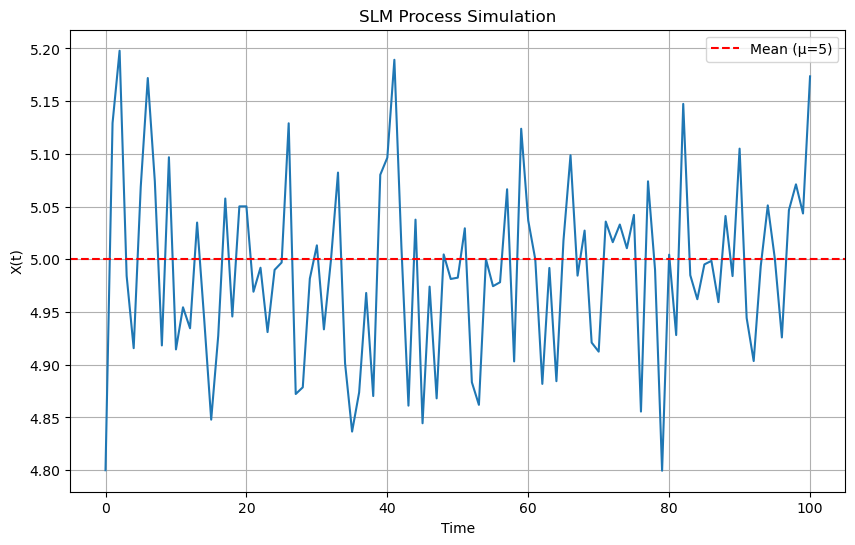

In [55]:
MODEL = 'SLM'

X0 = 4.8
k = 3
mu = 5
D = 0.005

dt = 3e-3 #timestep of the simulation

T = 100 #timeseries timespan, starts at 0 and ends at T
eff_dt = 1 #timestep of the datapoints
N = round(T+1 / eff_dt) #number of datapoints

timestepsperpoint = round(eff_dt / dt)

sim_data = simulate_timeseries(model=MODEL, params=(X0, k, mu, D, dt, timestepsperpoint, N))

# Plot result
plt.figure(figsize=(10, 6))
timepoints = np.linspace(0, T, N)
plt.plot(timepoints, sim_data)
plt.axhline(y=mu, color='r', linestyle='--', label=f'Mean (μ={mu})')
plt.xlabel('Time')
plt.ylabel('X(t)')
plt.title(f'{MODEL} Process Simulation')
plt.legend()
plt.grid(True)
plt.show()

In [56]:
lamperti_tf_data = SLM_Lamperti(sim_data)

/tmp/ipykernel_31747/421333305.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


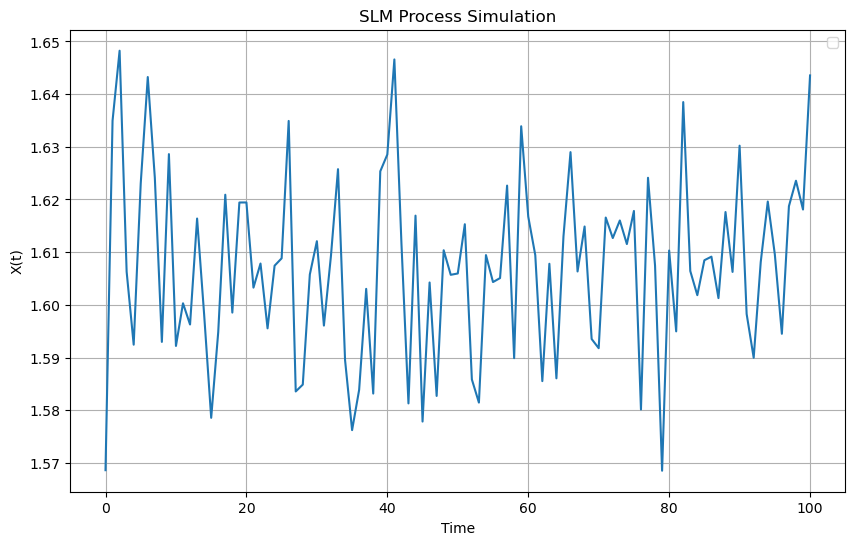

In [57]:
plt.figure(figsize=(10, 6))
timepoints = np.linspace(0, T, N)
plt.plot(timepoints, lamperti_tf_data)
# plt.axhline(y=mu, color='r', linestyle='--', label=f'Mean (μ={mu})')
plt.xlabel('Time')
plt.ylabel('X(t)')
plt.title(f'{MODEL} Process Simulation')
plt.legend()
plt.grid(True)
plt.show()

In [62]:
log_rho_tilde_array = log_propagators_transformed_data(lamperti_tf_data, NB, bridge_steps, Delta_t_B, D, k, mu, model=MODEL)

In [63]:
print(log_rho_tilde_array)

[-5053271.32889409 -4768913.32678204 -4910040.8275739  -5111509.32678964
 -5023728.32716264 -4819322.82689747 -4849228.32687622 -5048738.82717974
 -4999274.82732905 -5039763.32735665 -5130002.32672657 -5116773.82670192
 -5045240.82689615 -5056203.32685985 -5206475.326886   -5199596.82682637
 -5009698.32703349 -5043267.82694408 -5012869.82691218 -4944539.82669381
 -5021831.82682451 -5052840.82670429 -5095184.82676952 -5089120.82676458
 -5038584.32669479 -4909013.32703381 -5066446.32801219 -5234138.32669466
 -5132991.32691224 -5027612.32671378 -5082248.8268207  -5071420.8267816
 -4953155.32682896 -5065669.82734981 -5256245.32678242 -5276691.32672308
 -5145748.32687744 -5179325.32689132 -5043940.82758371 -4882246.3266989
 -4791452.32685665 -4892912.82729906 -5154461.32715896 -5092790.32732907
 -5149561.82745772 -5164762.82704225 -5168727.82692572 -5118421.8270761
 -5045054.82670466 -5060629.82669384 -5008343.82673751 -5119111.32712775
 -5251083.32670349 -5129218.82708578 -5058090.32670689

In [64]:
timeseries_logL = ts_logL(log_propagators_target_process(log_rho_tilde_array, sim_data, 'SLM'), 1.0)

In [65]:
timeseries_logL

np.float64(-504788196.43993485)

## 12. Efficiency Workshop

### 12.1. Numba

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import time

In [2]:
def BDM_step(X0, k, mu, D, dt, timestepsperpoint):
    t = np.linspace(0, timestepsperpoint - 1, timestepsperpoint)
    X = np.zeros(timestepsperpoint)
    X[0] = X0

    dW = D * np.random.normal(size=timestepsperpoint)

    #Euler-Maruyama iteration
    for i in range(1,timestepsperpoint):
        X[i] = X[i-1] + k * (mu - X[i-1]) * dt + np.sqrt(X[i-1]) * dW[i-1]

    return X[-1]
def BDM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N):
    datapoints = np.zeros(N)
    datapoints[0] = X0

    for idx in range(1,N):
        datapoints[idx] = BDM_step(datapoints[idx-1], k, mu, D, dt, timestepsperpoint)

    return datapoints
def SLM_step(X0, k, mu, D, dt, timestepsperpoint):
    t = np.linspace(0, timestepsperpoint - 1, timestepsperpoint)
    X = np.zeros(timestepsperpoint)
    X[0] = X0

    dW = D * np.random.normal(size=timestepsperpoint)

    #Euler-Maruyama iteration
    for i in range(1,timestepsperpoint):
        X[i] = X[i-1] + k * X[i-1] * (mu - X[i-1]) * dt + X[i-1] * dW[i-1]

    return X[-1]
def SLM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N):
    datapoints = np.zeros(N)
    datapoints[0] = X0

    for idx in range(1,N):
        datapoints[idx] = SLM_step(datapoints[idx-1], k, mu, D, dt, timestepsperpoint)

    return datapoints
def simulate_timeseries(model='BDM', params=None):
    
    valid_models = {"BDM", "SLM"}
    X0, k, mu, D, dt, timestepsperpoint, N = params

    if params == None:
        raise ValueError("No parameters passed to simulate_timeseries()!")
    
    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        sim_data = BDM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N)
    elif model == 'SLM':
        sim_data = SLM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N)
    return sim_data
    
def BDM_Lamperti(ts_data):
    arr = np.array(ts_data)      
    # Check for negative values
    if np.any(arr < 0):
        raise ValueError("Input array contains negative values. Square root is not defined for negative numbers.")    
    result = 2 * np.sqrt(arr)
    return result   
    
def SLM_Lamperti(ts_data):
    arr = np.array(ts_data)      
    # Check for negative values
    if np.any(arr < 0):
        raise ValueError("Input array contains negative values. Log is not defined for negative numbers.")    
    result = np.log(arr)
    return result
def bridge(NB, bridge_steps, x_i, x_f, Delta_t_B, D):        
    B = np.empty((NB, bridge_steps), dtype=np.float32) #to store simulated X values for bridges
    B[:, 0] = x_i
    B[:, -1] = x_f     
    for step in range(1, bridge_steps - 1): 
        #ATTENTION: Manal's script had (bridge_steps - step) * B[:, step - 1] + x_f with a PLUS!! Is this a grave typo in Javier's?
        mean_b = ((bridge_steps - step) * B[:, step - 1] + x_f ) / (bridge_steps - step + 1)        
        var_b = (D**2 * (bridge_steps - step) * Delta_t_B ) / (bridge_steps - step + 1)      
        B[:, step] = np.random.randn(NB) * np.sqrt(var_b) + mean_b    
    return B
def I_hat(k, mu, B, Delta_t_B, model='BDM'):
    
    valid_models = {"BDM", "SLM"}

    B = np.array(B)

    if B.ndim != 1:
        raise ValueError(f"Expected 1D array, but got {B.ndim}D array with shape {B.shape}")
    
    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        Ihat = np.sum(((2 * k * mu - 0.5 * k * B**2 - 0.5) / B)**2) * Delta_t_B
    elif model == 'SLM':
        Ihat = np.sum((k * (mu - np.exp(B)) - 0.5)**2) * Delta_t_B

    return Ihat

def Gaussian_PDF(x, mean, std_dev):
    return (1 / (std_dev * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std_dev)**2)

def log_RN_Derivative_BDM(B, k, mu, D, Delta_t_B, eff_dt):
    x_i = B[0]
    x_f = B[-1]

    Ihat = I_hat(k, mu, B, Delta_t_B, model='BDM')

    return (( 2 * k * mu * np.log(x_f/x_i) - 
              np.log(x_f/x_i) * 0.5 - 
              k * (x_f**2 - x_i**2) * 0.25 )/
            (D**2)) - (Ihat / ( 2 * (D**2) ) )

def log_RN_Derivative_SLM(B, k, mu, D, Delta_t_B, eff_dt):
    x_i = B[0]
    x_f = B[-1]

    Ihat = I_hat(k, mu, B, Delta_t_B, model='SLM')

    return (((k * mu - 0.5)*(x_f - x_i) - 
             k*(np.exp(x_f) - np.exp(x_i))
            ) / 
            (D**2)) - (Ihat / (2 * (D**2)))

def log_RN_Derivative(B, k, mu, D, Delta_t_B, eff_dt, model='BDM'):
    valid_models = {"BDM", "SLM"}

    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        return log_RN_Derivative_BDM(B, k, mu, D, Delta_t_B, eff_dt)
    elif model == 'SLM':
        return log_RN_Derivative_SLM(B, k, mu, D, Delta_t_B, eff_dt)

def logRND_each_bridge(bridges, k, mu, D, Delta_t_B, eff_dt, model='BDM'):

    #Array of L_t for each bridge
    logRND_array = np.array([])

    #For each bridge, calculate L and append to array
    for bridge in bridges:
        logRND_array = np.append(logRND_array, log_RN_Derivative(bridge, k, mu, D, Delta_t_B, eff_dt, model))

    return logRND_array

def est_log_propagator(bridges, k, mu, D, Delta_t_B, eff_dt, NB, x_i, x_f, model='BDM'):
    logRND_array = logRND_each_bridge(bridges, k, mu, D, Delta_t_B, model)
    lL_star = np.max(logRND_array)
    G = Gaussian_PDF(x_f, x_i, eff_dt)
    return lL_star + np.log(G) - np.log(NB) + np.log(np.sum(np.exp(logRND_array - lL_star)))

def log_propagators_transformed_data(data, NB, bridge_steps, Delta_t_B, D, k, mu, model='BDM'):
    
    log_rho_array = np.array([])

    successive_datapoints = np.column_stack((data[:-1], data[1:]))

    for x_i, x_f in successive_datapoints:
        bridges = bridge(NB, bridge_steps, x_i, x_f, Delta_t_B, D)
        log_propagator = est_log_propagator(bridges, k, mu, D, Delta_t_B, eff_dt, NB, x_i, x_f, model)
        log_rho_array = np.append(log_rho_array, log_propagator)

    return log_rho_array

def log_propagators_target_process(log_rho_array, data, model='BDM'):
    valid_models = {"BDM", "SLM"}

    data = data[1:]

    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        h_prime = 1 / np.sqrt(data)
        log_h_prime = np.log(h_prime)
        return log_h_prime + log_rho_array
    elif model == 'SLM':
        h_prime = 1 / data
        log_h_prime = np.log(h_prime)
        return log_h_prime + log_rho_array

def ts_logL(log_rho_array, p0):
    return np.sum(log_rho_array) + np.log(p0)

In [5]:
# Parameters

MODEL = 'SLM'

X0 = 4.8
k = 3
mu = 5
D = 0.005

dt = 3e-3 #timestep of the simulation

T = 100 #timeseries timespan, starts at 0 and ends at T
eff_dt = 1 #timestep of the datapoints
N = round(T+1 / eff_dt) #number of datapoints

timestepsperpoint = round(eff_dt / dt)

NB = 1000  # Number of bridges per transition
timestep_ratio = 1e3 # dt / Dt

bridge_steps = int(eff_dt * timestep_ratio) # Number of time steps inside bridge
Delta_t_B = eff_dt / bridge_steps 

datapoint_times = np.linspace(0, T, N)

In [10]:
start_time = time.time()
sim_data = simulate_timeseries(model=MODEL, params=(X0, k, mu, D, dt, timestepsperpoint, N))
end_time = time.time()
print(f"Execution time: {end_time - start_time:.6f} seconds")

Execution time: 0.035754 seconds


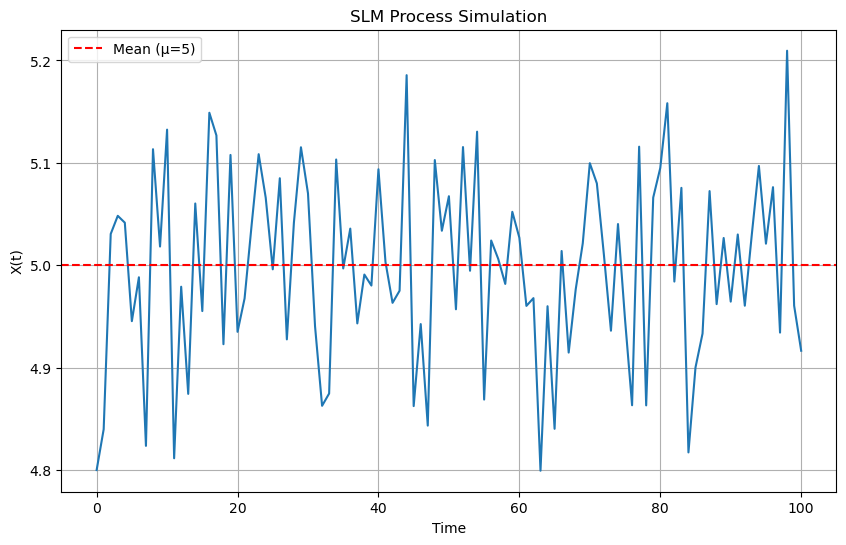

In [11]:
# Plot result
plt.figure(figsize=(10, 6))
timepoints = np.linspace(0, T, N)
plt.plot(timepoints, sim_data)
plt.axhline(y=mu, color='r', linestyle='--', label=f'Mean (μ={mu})')
plt.xlabel('Time')
plt.ylabel('X(t)')
plt.title(f'{MODEL} Process Simulation')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
start_time = time.time()

lamperti_tf_data = SLM_Lamperti(sim_data)

end_time = time.time()
print(f"Execution time: {end_time - start_time:.6f} seconds")

Execution time: 0.000106 seconds


In [13]:
start_time = time.time()

log_rho_tilde_array = log_propagators_transformed_data(lamperti_tf_data, NB, bridge_steps, Delta_t_B, D, k, mu, model=MODEL)

end_time = time.time()
print(f"Execution time: {end_time - start_time:.6f} seconds")

Execution time: 3.817766 seconds


In [14]:
start_time = time.time()

timeseries_logL = ts_logL(log_propagators_target_process(log_rho_tilde_array, sim_data, 'SLM'), 1.0)

end_time = time.time()
print(f"Execution time: {end_time - start_time:.6f} seconds")

Execution time: 0.000128 seconds


In [62]:
import matplotlib.pyplot as plt
import numpy as np
import time

from numba import njit, prange

In [70]:
# @njit
def BDM_step(X0, k, mu, D, dt, timestepsperpoint):
    t = np.linspace(0, timestepsperpoint - 1, timestepsperpoint)
    X = np.zeros(timestepsperpoint)
    X[0] = X0

    dW = D * np.random.normal(size=timestepsperpoint)

    #Euler-Maruyama iteration
    for i in range(1,timestepsperpoint):
        X[i] = X[i-1] + k * (mu - X[i-1]) * dt + np.sqrt(X[i-1]) * dW[i-1]

    return X[-1]

# @njit
def BDM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N):
    datapoints = np.zeros(N)
    datapoints[0] = X0

    for idx in range(1,N):
        datapoints[idx] = BDM_step(datapoints[idx-1], k, mu, D, dt, timestepsperpoint)

    return datapoints

# @njit
def SLM_step(X0, k, mu, D, dt, timestepsperpoint):
    t = np.linspace(0, timestepsperpoint - 1, timestepsperpoint)
    X = np.zeros(timestepsperpoint)
    X[0] = X0

    dW = D * np.random.normal(size=timestepsperpoint)

    #Euler-Maruyama iteration
    for i in range(1,timestepsperpoint):
        X[i] = X[i-1] + k * X[i-1] * (mu - X[i-1]) * dt + X[i-1] * dW[i-1]

    return X[-1]

# @njit
def SLM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N):
    datapoints = np.zeros(N)
    datapoints[0] = X0

    for idx in range(1,N):
        datapoints[idx] = SLM_step(datapoints[idx-1], k, mu, D, dt, timestepsperpoint)

    return datapoints

# @njit
def simulate_timeseries(model='BDM', params=None):
    
    valid_models = {"BDM", "SLM"}
    X0, k, mu, D, dt, timestepsperpoint, N = params

    if params == None:
        raise ValueError("No parameters passed to simulate_timeseries()!")
    
    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        sim_data = BDM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N)
    elif model == 'SLM':
        sim_data = SLM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N)
    return sim_data

@njit
def BDM_Lamperti(ts_data):
    arr = ts_data      
    # Check for negative values
    if np.any(arr < 0):
        raise ValueError("Input array contains negative values. Square root is not defined for negative numbers.")    
    result = 2 * np.sqrt(arr)
    return result   

@njit
def SLM_Lamperti(ts_data):
    arr = ts_data      
    # Check for negative values
    if np.any(arr < 0):
        raise ValueError("Input array contains negative values. Log is not defined for negative numbers.")    
    result = np.log(arr)
    return result

@njit
def bridge(NB, bridge_steps, x_i, x_f, Delta_t_B, D):        
    B = np.empty((NB, bridge_steps), dtype=np.float32) #to store simulated X values for bridges
    B[:, 0] = x_i
    B[:, -1] = x_f     
    for step in range(1, bridge_steps - 1): 
        #ATTENTION: Manal's script had (bridge_steps - step) * B[:, step - 1] + x_f with a PLUS!! Is this a grave typo in Javier's?
        mean_b = ((bridge_steps - step) * B[:, step - 1] + x_f ) / (bridge_steps - step + 1)        
        var_b = (D**2 * (bridge_steps - step) * Delta_t_B ) / (bridge_steps - step + 1)      
        B[:, step] = np.random.randn(NB) * np.sqrt(var_b) + mean_b    
    return B

@njit
def I_hat(k, mu, B, Delta_t_B, model='BDM'):
    
    valid_models = {"BDM", "SLM"}

    # B = np.array(B)

    if B.ndim != 1:
        raise ValueError(f"Expected 1D array, but got {B.ndim}D array with shape {B.shape}")
    
    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        Ihat = np.sum(((2 * k * mu - 0.5 * k * B**2 - 0.5) / B)**2) * Delta_t_B
    elif model == 'SLM':
        Ihat = np.sum((k * (mu - np.exp(B)) - 0.5)**2) * Delta_t_B

    return Ihat

@njit
def Gaussian_PDF(x, mean, std_dev):
    return (1 / (std_dev * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std_dev)**2)

@njit
def log_RN_Derivative_BDM(B, k, mu, D, Delta_t_B, eff_dt):
    x_i = B[0]
    x_f = B[-1]

    Ihat = I_hat(k, mu, B, Delta_t_B, model='BDM')

    return (( 2 * k * mu * np.log(x_f/x_i) - 
              np.log(x_f/x_i) * 0.5 - 
              k * (x_f**2 - x_i**2) * 0.25 )/
            (D**2)) - (Ihat / ( 2 * (D**2) ) )

@njit
def log_RN_Derivative_SLM(B, k, mu, D, Delta_t_B, eff_dt):
    x_i = B[0]
    x_f = B[-1]

    Ihat = I_hat(k, mu, B, Delta_t_B, model='SLM')

    return (((k * mu - 0.5)*(x_f - x_i) - 
             k*(np.exp(x_f) - np.exp(x_i))
            ) / 
            (D**2)) - (Ihat / (2 * (D**2)))

@njit
def log_RN_Derivative(B, k, mu, D, Delta_t_B, eff_dt, model='BDM'):
    valid_models = {"BDM", "SLM"}

    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        return log_RN_Derivative_BDM(B, k, mu, D, Delta_t_B, eff_dt)
    elif model == 'SLM':
        return log_RN_Derivative_SLM(B, k, mu, D, Delta_t_B, eff_dt)

@njit(parallel=True)
def logRND_each_bridge(bridges, k, mu, D, Delta_t_B, eff_dt, model='BDM'):

    # Pre-allocate the result array with the correct size
    n_bridges = len(bridges)
    logRND_array = np.empty(n_bridges)  # Pre-allocate
    
    # #Array of L_t for each bridge
    # logRND_array = np.array([])

    #For each bridge, calculate L and append to array
    for i in prange(n_bridges):
        bridge = bridges[i]
        logRND_array[i] = log_RN_Derivative(bridge, k, mu, D, Delta_t_B, eff_dt, model)

    return logRND_array

@njit
def est_log_propagator(bridges, k, mu, D, Delta_t_B, eff_dt, NB, x_i, x_f, model='BDM'):
    logRND_array = logRND_each_bridge(bridges, k, mu, D, Delta_t_B, model)
    lL_star = np.max(logRND_array)
    G = Gaussian_PDF(x_f, x_i, eff_dt)
    return lL_star + np.log(G) - np.log(NB) + np.log(np.sum(np.exp(logRND_array - lL_star)))

@njit(parallel=True)
def log_propagators_transformed_data(data, NB, bridge_steps, Delta_t_B, D, k, mu, model='BDM'):
    
    # log_rho_array = np.array([])

    # successive_datapoints = np.column_stack((data[:-1], data[1:]))

    # Pre-allocate result array
    n_pairs = len(data) - 1
    log_rho_array = np.empty(n_pairs)  # Pre-allocate with correct size

    for i in prange(n_pairs):
        x_i = data[i]
        x_f = data[i + 1]
        
        bridges = bridge(NB, bridge_steps, x_i, x_f, Delta_t_B, D)
        log_propagator = est_log_propagator(bridges, k, mu, D, Delta_t_B, eff_dt, NB, x_i, x_f, model)
        # log_rho_array = np.append(log_rho_array, log_propagator)
        log_rho_array[i] = log_propagator

    return log_rho_array

@njit
def log_propagators_target_process(log_rho_array, data, model='BDM'):
    valid_models = {"BDM", "SLM"}

    data = data[1:]

    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        h_prime = 1 / np.sqrt(data)
        log_h_prime = np.log(h_prime)
        return log_h_prime + log_rho_array
    elif model == 'SLM':
        h_prime = 1 / data
        log_h_prime = np.log(h_prime)
        return log_h_prime + log_rho_array

@njit
def ts_logL(log_rho_array, p0):
    return np.sum(log_rho_array) + np.log(p0)

In [71]:
# Parameters

MODEL = 'SLM'

X0 = 4.8
k = 3
mu = 5
D = 0.005

dt = 3e-3 #timestep of the simulation

T = 100 #timeseries timespan, starts at 0 and ends at T
eff_dt = 1 #timestep of the datapoints
N = round(T+1 / eff_dt) #number of datapoints

timestepsperpoint = round(eff_dt / dt)

NB = 1000  # Number of bridges per transition
timestep_ratio = 1e3 # dt / Dt

bridge_steps = int(eff_dt * timestep_ratio) # Number of time steps inside bridge
Delta_t_B = eff_dt / bridge_steps 

datapoint_times = np.linspace(0, T, N)

In [4]:
start_time = time.time()
sim_data = simulate_timeseries(model=MODEL, params=(X0, k, mu, D, dt, timestepsperpoint, N))
end_time = time.time()
print(f"Execution time: {end_time - start_time:.6f} seconds")

Execution time: 0.033838 seconds


Numba has problems with the random number generator in numpy! Not using numba for the simulation.

In [61]:
start_time = time.time()

lamperti_tf_data = SLM_Lamperti(sim_data)

end_time = time.time()
print(f"Execution time: {end_time - start_time:.6f} seconds")

Execution time: 0.000066 seconds


25% faster. Not bad. But must now be sure to pass it numpy arrays!

In [73]:
start_time = time.time()

log_rho_tilde_array = log_propagators_transformed_data(lamperti_tf_data, NB, bridge_steps, Delta_t_B, D, k, mu, model=MODEL)

end_time = time.time()
print(f"Execution time: {end_time - start_time:.6f} seconds")

Execution time: 0.380063 seconds


In [75]:
start_time = time.time()

timeseries_logL = ts_logL(log_propagators_target_process(log_rho_tilde_array, sim_data, 'SLM'), 1.0)

end_time = time.time()
print(f"Execution time: {end_time - start_time:.6f} seconds")

Execution time: 0.000100 seconds


#### Python with numpy vs. using numba with parallelization - full comparison

python with numpy:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import time

def BDM_step(X0, k, mu, D, dt, timestepsperpoint):
    t = np.linspace(0, timestepsperpoint - 1, timestepsperpoint)
    X = np.zeros(timestepsperpoint)
    X[0] = X0

    dW = D * np.random.normal(size=timestepsperpoint)

    #Euler-Maruyama iteration
    for i in range(1,timestepsperpoint):
        X[i] = X[i-1] + k * (mu - X[i-1]) * dt + np.sqrt(X[i-1]) * dW[i-1]

    return X[-1]
def BDM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N):
    datapoints = np.zeros(N)
    datapoints[0] = X0

    for idx in range(1,N):
        datapoints[idx] = BDM_step(datapoints[idx-1], k, mu, D, dt, timestepsperpoint)

    return datapoints
def SLM_step(X0, k, mu, D, dt, timestepsperpoint):
    t = np.linspace(0, timestepsperpoint - 1, timestepsperpoint)
    X = np.zeros(timestepsperpoint)
    X[0] = X0

    dW = D * np.random.normal(size=timestepsperpoint)

    #Euler-Maruyama iteration
    for i in range(1,timestepsperpoint):
        X[i] = X[i-1] + k * X[i-1] * (mu - X[i-1]) * dt + X[i-1] * dW[i-1]

    return X[-1]
def SLM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N):
    datapoints = np.zeros(N)
    datapoints[0] = X0

    for idx in range(1,N):
        datapoints[idx] = SLM_step(datapoints[idx-1], k, mu, D, dt, timestepsperpoint)

    return datapoints
def simulate_timeseries(model='BDM', params=None):
    
    valid_models = {"BDM", "SLM"}
    X0, k, mu, D, dt, timestepsperpoint, N = params

    if params == None:
        raise ValueError("No parameters passed to simulate_timeseries()!")
    
    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        sim_data = BDM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N)
    elif model == 'SLM':
        sim_data = SLM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N)
    return sim_data
    
def BDM_Lamperti(ts_data):
    arr = np.array(ts_data)      
    # Check for negative values
    if np.any(arr < 0):
        raise ValueError("Input array contains negative values. Square root is not defined for negative numbers.")    
    result = 2 * np.sqrt(arr)
    return result   
    
def SLM_Lamperti(ts_data):
    arr = np.array(ts_data)      
    # Check for negative values
    if np.any(arr < 0):
        raise ValueError("Input array contains negative values. Log is not defined for negative numbers.")    
    result = np.log(arr)
    return result
def bridge(NB, bridge_steps, x_i, x_f, Delta_t_B, D):        
    B = np.empty((NB, bridge_steps), dtype=np.float32) #to store simulated X values for bridges
    B[:, 0] = x_i
    B[:, -1] = x_f     
    for step in range(1, bridge_steps - 1): 
        #ATTENTION: Manal's script had (bridge_steps - step) * B[:, step - 1] + x_f with a PLUS!! Is this a grave typo in Javier's?
        mean_b = ((bridge_steps - step) * B[:, step - 1] + x_f ) / (bridge_steps - step + 1)        
        var_b = (D**2 * (bridge_steps - step) * Delta_t_B ) / (bridge_steps - step + 1)      
        B[:, step] = np.random.randn(NB) * np.sqrt(var_b) + mean_b    
    return B
def I_hat(k, mu, B, Delta_t_B, model='BDM'):
    
    valid_models = {"BDM", "SLM"}

    B = np.array(B)

    if B.ndim != 1:
        raise ValueError(f"Expected 1D array, but got {B.ndim}D array with shape {B.shape}")
    
    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        Ihat = np.sum(((2 * k * mu - 0.5 * k * B**2 - 0.5) / B)**2) * Delta_t_B
    elif model == 'SLM':
        Ihat = np.sum((k * (mu - np.exp(B)) - 0.5)**2) * Delta_t_B

    return Ihat

def Gaussian_PDF(x, mean, std_dev):
    return (1 / (std_dev * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std_dev)**2)

def log_RN_Derivative_BDM(B, k, mu, D, Delta_t_B, eff_dt):
    x_i = B[0]
    x_f = B[-1]

    Ihat = I_hat(k, mu, B, Delta_t_B, model='BDM')

    return (( 2 * k * mu * np.log(x_f/x_i) - 
              np.log(x_f/x_i) * 0.5 - 
              k * (x_f**2 - x_i**2) * 0.25 )/
            (D**2)) - (Ihat / ( 2 * (D**2) ) )

def log_RN_Derivative_SLM(B, k, mu, D, Delta_t_B, eff_dt):
    x_i = B[0]
    x_f = B[-1]

    Ihat = I_hat(k, mu, B, Delta_t_B, model='SLM')

    return (((k * mu - 0.5)*(x_f - x_i) - 
             k*(np.exp(x_f) - np.exp(x_i))
            ) / 
            (D**2)) - (Ihat / (2 * (D**2)))

def log_RN_Derivative(B, k, mu, D, Delta_t_B, eff_dt, model='BDM'):
    valid_models = {"BDM", "SLM"}

    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        return log_RN_Derivative_BDM(B, k, mu, D, Delta_t_B, eff_dt)
    elif model == 'SLM':
        return log_RN_Derivative_SLM(B, k, mu, D, Delta_t_B, eff_dt)

def logRND_each_bridge(bridges, k, mu, D, Delta_t_B, eff_dt, model='BDM'):

    #Array of L_t for each bridge
    logRND_array = np.array([])

    #For each bridge, calculate L and append to array
    for bridge in bridges:
        logRND_array = np.append(logRND_array, log_RN_Derivative(bridge, k, mu, D, Delta_t_B, eff_dt, model))

    return logRND_array

def est_log_propagator(bridges, k, mu, D, Delta_t_B, eff_dt, NB, x_i, x_f, model='BDM'):
    logRND_array = logRND_each_bridge(bridges, k, mu, D, Delta_t_B, model)
    lL_star = np.max(logRND_array)
    G = Gaussian_PDF(x_f, x_i, eff_dt)
    return lL_star + np.log(G) - np.log(NB) + np.log(np.sum(np.exp(logRND_array - lL_star)))

def log_propagators_transformed_data(data, NB, bridge_steps, Delta_t_B, D, k, mu, model='BDM'):
    
    log_rho_array = np.array([])

    successive_datapoints = np.column_stack((data[:-1], data[1:]))

    for x_i, x_f in successive_datapoints:
        bridges = bridge(NB, bridge_steps, x_i, x_f, Delta_t_B, D)
        log_propagator = est_log_propagator(bridges, k, mu, D, Delta_t_B, eff_dt, NB, x_i, x_f, model)
        log_rho_array = np.append(log_rho_array, log_propagator)

    return log_rho_array

def log_propagators_target_process(log_rho_array, data, model='BDM'):
    valid_models = {"BDM", "SLM"}

    data = data[1:]

    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        h_prime = 1 / np.sqrt(data)
        log_h_prime = np.log(h_prime)
        return log_h_prime + log_rho_array
    elif model == 'SLM':
        h_prime = 1 / data
        log_h_prime = np.log(h_prime)
        return log_h_prime + log_rho_array

def ts_logL(log_rho_array, p0):
    return np.sum(log_rho_array) + np.log(p0)


# Parameters

MODEL = 'SLM'

X0 = 4.8
k = 3
mu = 5
D = 0.005

dt = 3e-3 #timestep of the simulation

T = 100 #timeseries timespan, starts at 0 and ends at T
eff_dt = 1 #timestep of the datapoints
N = round(T+1 / eff_dt) #number of datapoints

timestepsperpoint = round(eff_dt / dt)

NB = 1000  # Number of bridges per transition
timestep_ratio = 1e3 # dt / Dt

bridge_steps = int(eff_dt * timestep_ratio) # Number of time steps inside bridge
Delta_t_B = eff_dt / bridge_steps 

datapoint_times = np.linspace(0, T, N)

In [2]:
#Simulating data
start_time = time.time()
sim_data = simulate_timeseries(model=MODEL, params=(X0, k, mu, D, dt, timestepsperpoint, N))
end_time = time.time()
sim_time_no_numba = end_time - start_time
print(f"Execution time: {end_time - start_time:.6f} seconds")

Execution time: 0.040224 seconds


In [3]:
start_time = time.time()

lamperti_tf_data = SLM_Lamperti(sim_data)
log_rho_tilde_array = log_propagators_transformed_data(lamperti_tf_data, NB, bridge_steps, Delta_t_B, D, k, mu, model=MODEL)
timeseries_logL = ts_logL(log_propagators_target_process(log_rho_tilde_array, sim_data, 'SLM'), 1.0)

end_time = time.time()
ts_time_no_numba = end_time - start_time
print(f"Execution time: {end_time - start_time:.6f} seconds")

Execution time: 3.677299 seconds


python with numba and parallelization:

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import time

from numba import njit, prange

# @njit
def BDM_step(X0, k, mu, D, dt, timestepsperpoint):
    t = np.linspace(0, timestepsperpoint - 1, timestepsperpoint)
    X = np.zeros(timestepsperpoint)
    X[0] = X0

    dW = D * np.random.normal(size=timestepsperpoint)

    #Euler-Maruyama iteration
    for i in range(1,timestepsperpoint):
        X[i] = X[i-1] + k * (mu - X[i-1]) * dt + np.sqrt(X[i-1]) * dW[i-1]

    return X[-1]

# @njit
def BDM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N):
    datapoints = np.zeros(N)
    datapoints[0] = X0

    for idx in range(1,N):
        datapoints[idx] = BDM_step(datapoints[idx-1], k, mu, D, dt, timestepsperpoint)

    return datapoints

# @njit
def SLM_step(X0, k, mu, D, dt, timestepsperpoint):
    t = np.linspace(0, timestepsperpoint - 1, timestepsperpoint)
    X = np.zeros(timestepsperpoint)
    X[0] = X0

    dW = D * np.random.normal(size=timestepsperpoint)

    #Euler-Maruyama iteration
    for i in range(1,timestepsperpoint):
        X[i] = X[i-1] + k * X[i-1] * (mu - X[i-1]) * dt + X[i-1] * dW[i-1]

    return X[-1]

# @njit
def SLM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N):
    datapoints = np.zeros(N)
    datapoints[0] = X0

    for idx in range(1,N):
        datapoints[idx] = SLM_step(datapoints[idx-1], k, mu, D, dt, timestepsperpoint)

    return datapoints

# @njit
def simulate_timeseries(model='BDM', params=None):
    
    valid_models = {"BDM", "SLM"}
    X0, k, mu, D, dt, timestepsperpoint, N = params

    if params == None:
        raise ValueError("No parameters passed to simulate_timeseries()!")
    
    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        sim_data = BDM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N)
    elif model == 'SLM':
        sim_data = SLM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N)
    return sim_data

@njit
def BDM_Lamperti(ts_data):
    arr = ts_data      
    # Check for negative values
    if np.any(arr < 0):
        raise ValueError("Input array contains negative values. Square root is not defined for negative numbers.")    
    result = 2 * np.sqrt(arr)
    return result   

@njit
def SLM_Lamperti(ts_data):
    arr = ts_data      
    # Check for negative values
    if np.any(arr < 0):
        raise ValueError("Input array contains negative values. Log is not defined for negative numbers.")    
    result = np.log(arr)
    return result

@njit
def bridge(NB, bridge_steps, x_i, x_f, Delta_t_B, D):        
    B = np.empty((NB, bridge_steps), dtype=np.float32) #to store simulated X values for bridges
    B[:, 0] = x_i
    B[:, -1] = x_f     
    for step in range(1, bridge_steps - 1): 
        #ATTENTION: Manal's script had (bridge_steps - step) * B[:, step - 1] + x_f with a PLUS!! Is this a grave typo in Javier's?
        mean_b = ((bridge_steps - step) * B[:, step - 1] + x_f ) / (bridge_steps - step + 1)        
        var_b = (D**2 * (bridge_steps - step) * Delta_t_B ) / (bridge_steps - step + 1)      
        B[:, step] = np.random.randn(NB) * np.sqrt(var_b) + mean_b    
    return B

@njit
def I_hat(k, mu, B, Delta_t_B, model='BDM'):
    
    valid_models = {"BDM", "SLM"}

    # B = np.array(B)

    if B.ndim != 1:
        raise ValueError(f"Expected 1D array, but got {B.ndim}D array with shape {B.shape}")
    
    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        Ihat = np.sum(((2 * k * mu - 0.5 * k * B**2 - 0.5) / B)**2) * Delta_t_B
    elif model == 'SLM':
        Ihat = np.sum((k * (mu - np.exp(B)) - 0.5)**2) * Delta_t_B

    return Ihat

@njit
def Gaussian_PDF(x, mean, std_dev):
    return (1 / (std_dev * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std_dev)**2)

@njit
def log_RN_Derivative_BDM(B, k, mu, D, Delta_t_B, eff_dt):
    x_i = B[0]
    x_f = B[-1]

    Ihat = I_hat(k, mu, B, Delta_t_B, model='BDM')

    return (( 2 * k * mu * np.log(x_f/x_i) - 
              np.log(x_f/x_i) * 0.5 - 
              k * (x_f**2 - x_i**2) * 0.25 )/
            (D**2)) - (Ihat / ( 2 * (D**2) ) )

@njit
def log_RN_Derivative_SLM(B, k, mu, D, Delta_t_B, eff_dt):
    x_i = B[0]
    x_f = B[-1]

    Ihat = I_hat(k, mu, B, Delta_t_B, model='SLM')

    return (((k * mu - 0.5)*(x_f - x_i) - 
             k*(np.exp(x_f) - np.exp(x_i))
            ) / 
            (D**2)) - (Ihat / (2 * (D**2)))

@njit
def log_RN_Derivative(B, k, mu, D, Delta_t_B, eff_dt, model='BDM'):
    valid_models = {"BDM", "SLM"}

    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        return log_RN_Derivative_BDM(B, k, mu, D, Delta_t_B, eff_dt)
    elif model == 'SLM':
        return log_RN_Derivative_SLM(B, k, mu, D, Delta_t_B, eff_dt)

@njit(parallel=True)
def logRND_each_bridge(bridges, k, mu, D, Delta_t_B, eff_dt, model='BDM'):

    # Pre-allocate the result array with the correct size
    n_bridges = len(bridges)
    logRND_array = np.empty(n_bridges)  # Pre-allocate
    
    # #Array of L_t for each bridge
    # logRND_array = np.array([])

    #For each bridge, calculate L and append to array
    for i in prange(n_bridges):
        bridge = bridges[i]
        logRND_array[i] = log_RN_Derivative(bridge, k, mu, D, Delta_t_B, eff_dt, model)

    return logRND_array

@njit
def est_log_propagator(bridges, k, mu, D, Delta_t_B, eff_dt, NB, x_i, x_f, model='BDM'):
    logRND_array = logRND_each_bridge(bridges, k, mu, D, Delta_t_B, model)
    lL_star = np.max(logRND_array)
    G = Gaussian_PDF(x_f, x_i, eff_dt)
    return lL_star + np.log(G) - np.log(NB) + np.log(np.sum(np.exp(logRND_array - lL_star)))

@njit(parallel=True)
def log_propagators_transformed_data(data, NB, bridge_steps, Delta_t_B, D, k, mu, model='BDM'):
    
    # log_rho_array = np.array([])

    # successive_datapoints = np.column_stack((data[:-1], data[1:]))

    # Pre-allocate result array
    n_pairs = len(data) - 1
    log_rho_array = np.empty(n_pairs)  # Pre-allocate with correct size

    for i in prange(n_pairs):
        x_i = data[i]
        x_f = data[i + 1]
        
        bridges = bridge(NB, bridge_steps, x_i, x_f, Delta_t_B, D)
        log_propagator = est_log_propagator(bridges, k, mu, D, Delta_t_B, eff_dt, NB, x_i, x_f, model)
        # log_rho_array = np.append(log_rho_array, log_propagator)
        log_rho_array[i] = log_propagator

    return log_rho_array

@njit
def log_propagators_target_process(log_rho_array, data, model='BDM'):
    valid_models = {"BDM", "SLM"}

    data = data[1:]

    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        h_prime = 1 / np.sqrt(data)
        log_h_prime = np.log(h_prime)
        return log_h_prime + log_rho_array
    elif model == 'SLM':
        h_prime = 1 / data
        log_h_prime = np.log(h_prime)
        return log_h_prime + log_rho_array

@njit
def ts_logL(log_rho_array, p0):
    return np.sum(log_rho_array) + np.log(p0)

# Parameters

MODEL = 'SLM'

X0 = 4.8
k = 3
mu = 5
D = 0.005

dt = 3e-3 #timestep of the simulation

T = 100 #timeseries timespan, starts at 0 and ends at T
eff_dt = 1 #timestep of the datapoints
N = round(T+1 / eff_dt) #number of datapoints

timestepsperpoint = round(eff_dt / dt)

NB = 1000  # Number of bridges per transition
timestep_ratio = 1e3 # dt / Dt

bridge_steps = int(eff_dt * timestep_ratio) # Number of time steps inside bridge
Delta_t_B = eff_dt / bridge_steps 

datapoint_times = np.linspace(0, T, N)

In [7]:
#Simulating data
start_time = time.time()
sim_data = simulate_timeseries(model=MODEL, params=(X0, k, mu, D, dt, timestepsperpoint, N))
end_time = time.time()
sim_time_numba = end_time - start_time
print(f"Execution time: {end_time - start_time:.6f} seconds")

Execution time: 0.034773 seconds


In [8]:
start_time = time.time()

lamperti_tf_data = SLM_Lamperti(sim_data)
log_rho_tilde_array = log_propagators_transformed_data(lamperti_tf_data, NB, bridge_steps, Delta_t_B, D, k, mu, model=MODEL)
timeseries_logL = ts_logL(log_propagators_target_process(log_rho_tilde_array, sim_data, 'SLM'), 1.0)

end_time = time.time()
ts_time_numba = end_time - start_time
print(f"Execution time: {end_time - start_time:.6f} seconds")

Execution time: 0.380805 seconds


In [10]:
print(f"Calculating the timeseries likelihood with numba and parallelization is {round(ts_time_no_numba / ts_time_numba, 2)}x faster.")

Calculating the timeseries likelihood with numba and parallelization is 9.66x faster.
